## 4.1 Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
from itertools import product
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('../data/rainfall_fe.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

TARGET    = 'temp'

print(f'Loaded  : {df.shape[0]:,} observations  |  {df.shape[1]} variables')
print(f'Period  : {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'Target  : {TARGET}  |  Mean={df[TARGET].mean():.2f}°C')

Loaded  : 1,774 observations  |  25 variables
Period  : 2016-01-08 → 2020-11-15
Target  : temp  |  Mean=28.35°C


## 4.2 Stationarity Test (ADF)

In [3]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'=== ADF Test — {name} ===')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical 1%   : {result[4]["1%"]:.4f}')
    print(f'  Critical 5%   : {result[4]["5%"]:.4f}')
    stationary = result[1] < 0.05
    print(f'  → {"STATIONARY" if stationary else "NON-STATIONARY"} at α=0.05')
    return stationary

is_stationary    = adf_test(df[TARGET], name='temp (original)')
print()
diff1            = df[TARGET].diff().dropna()
is_stationary_d1 = adf_test(diff1, name='temp (first difference d=1)')

=== ADF Test — temp (original) ===
  ADF Statistic : -4.6171
  p-value       : 0.0001
  Critical 1%   : -3.4341
  Critical 5%   : -2.8632
  → STATIONARY at α=0.05

=== ADF Test — temp (first difference d=1) ===
  ADF Statistic : -16.3910
  p-value       : 0.0000
  Critical 1%   : -3.4341
  Critical 5%   : -2.8632
  → STATIONARY at α=0.05


## 4.3 ACF & PACF — Parameter Identification

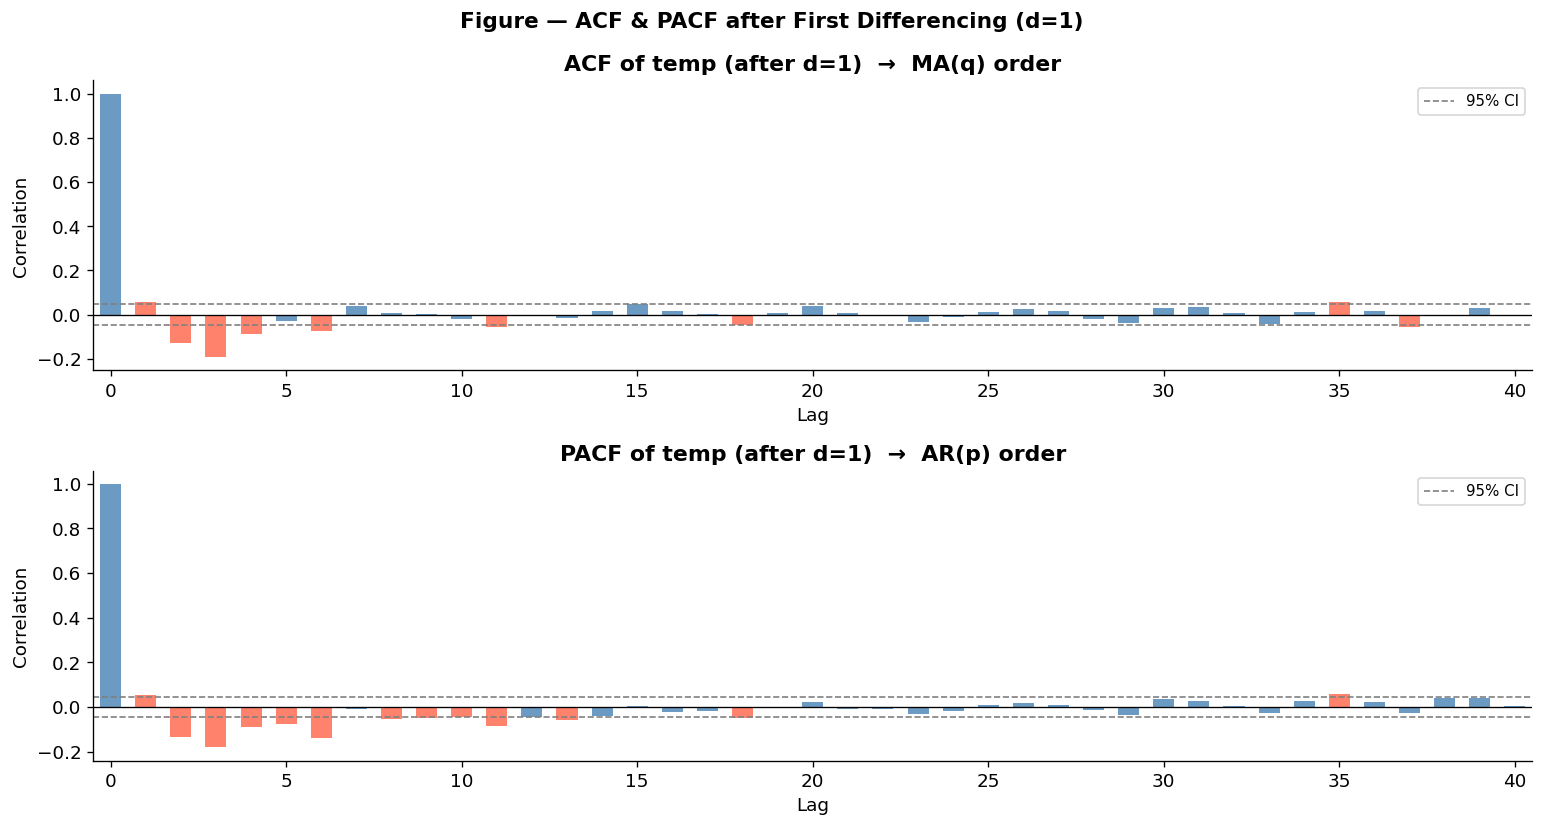

ACF  lags 1-5: [np.float64(0.056), np.float64(-0.13), np.float64(-0.193), np.float64(-0.087), np.float64(-0.028)]
PACF lags 1-5: [np.float64(0.056), np.float64(-0.133), np.float64(-0.182), np.float64(-0.09), np.float64(-0.074)]
95% CI band  : ±0.0465


In [4]:
diff1 = df[TARGET].diff().dropna()
n     = len(diff1)
nlags = 40
conf  = 1.96 / np.sqrt(n)

acf_vals  = acf(diff1,  nlags=nlags, fft=True)
pacf_vals = pacf(diff1, nlags=nlags)

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, vals, title in zip(axes,
    [acf_vals, pacf_vals],
    ['ACF of temp (after d=1)  →  MA(q) order',
     'PACF of temp (after d=1)  →  AR(p) order']):
    lags   = np.arange(len(vals))
    colors = ['tomato' if abs(v) > conf and i > 0 else 'steelblue'
              for i, v in enumerate(vals)]
    ax.bar(lags, vals, color=colors, alpha=0.8, width=0.6)
    ax.axhline( conf, color='gray', linestyle='--', linewidth=1, label='95% CI')
    ax.axhline(-conf, color='gray', linestyle='--', linewidth=1)
    ax.axhline(0,     color='black', linewidth=0.8)
    ax.set_xlabel('Lag')
    ax.set_ylabel('Correlation')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(-0.5, nlags + 0.5)

fig.suptitle('Figure — ACF & PACF after First Differencing (d=1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_acf_pacf_diff.png', bbox_inches='tight')
plt.show()
print(f'ACF  lags 1-5: {[round(v,3) for v in acf_vals[1:6]]}')
print(f'PACF lags 1-5: {[round(v,3) for v in pacf_vals[1:6]]}')
print(f'95% CI band  : ±{conf:.4f}')

## 4.4 Train / Test Split

Train : 1,454 obs  |  2016-01-08 → 2019-12-31
Test  :   320 obs  |  2020-01-01  → 2020-11-15
Split : 82.0% train  /  18.0% test


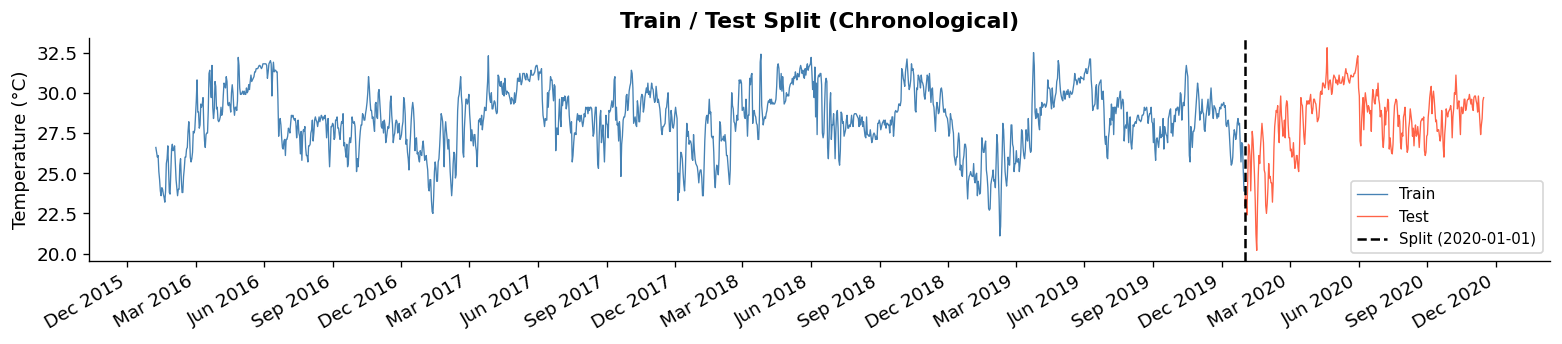

In [5]:
SPLIT_DATE = '2020-01-01'
train = df[df['datetime'] <  SPLIT_DATE].reset_index(drop=True)
test  = df[df['datetime'] >= SPLIT_DATE].reset_index(drop=True)

print(f'Train : {train.shape[0]:>5,} obs  |  {train["datetime"].min().date()} → {train["datetime"].max().date()}')
print(f'Test  : {test.shape[0]:>5,} obs  |  {test["datetime"].min().date()}  → {test["datetime"].max().date()}')
print(f'Split : {len(train)/len(df)*100:.1f}% train  /  {len(test)/len(df)*100:.1f}% test')

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(train['datetime'], train[TARGET], color='steelblue', linewidth=0.8, label='Train')
ax.plot(test['datetime'],  test[TARGET],  color='tomato',    linewidth=0.8, label='Test')
ax.axvline(pd.Timestamp(SPLIT_DATE), color='black', linestyle='--',
           linewidth=1.5, label=f'Split ({SPLIT_DATE})')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Train / Test Split (Chronological)', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_train_test_split.png', bbox_inches='tight')
plt.show()

## 4.5 Data Leakage Check (Read-Only)

> Verify that lag and rolling features were constructed correctly.
> This cell does **not** modify any data.

In [6]:
print('=== Data Leakage Check ===')

# 1. temp_lag1 at row t should equal temp at row t-1
lag_ok = (df['temp_lag1'].iloc[1:].values == df['temp'].iloc[:-1].values).all()
print(f'  temp_lag1 = temp.shift(1)      : {"✓ OK" if lag_ok else "✗ LEAKAGE"}')

# 2. temp_rollmean7 must use rows t-7 to t-1 (not t)
idx         = 50
manual_roll = df['temp'].iloc[idx-7:idx].mean()
stored_roll = df['temp_rollmean7'].iloc[idx]
roll_ok     = abs(manual_roll - stored_roll) < 0.001
print(f'  temp_rollmean7 uses past only  : {"✓ OK" if roll_ok else "✗ LEAKAGE"}')

# 3. Scaling will be fitted on train only
print(f'  Scaling fitted on train only   : ✓ confirmed in cells below')
print('\n✓ No data leakage detected.')

=== Data Leakage Check ===
  temp_lag1 = temp.shift(1)      : ✓ OK
  temp_rollmean7 uses past only  : ✓ OK
  Scaling fitted on train only   : ✓ confirmed in cells below

✓ No data leakage detected.


## 4.6 Setup train_scaled / test_scaled for SARIMA

> Cell 4.6 previously scaled `EXOG_COLS` here, but this is redundant:
> SARIMAX independently scales its 4 Granger-significant variables in cell 4.12,
> and XGBoost scales its own features in cell 4.15.
> SARIMA uses no exogenous variables at all.
> Therefore, only the copy is needed here.

In [7]:
# SARIMA uses train_scaled[TARGET] only — no exogenous scaling needed here
# SARIMAX scales its own 4 Granger variables independently in cell 4.12
# XGBoost  scales its own 20 features independently in cell 4.15
train_scaled = train.copy()
test_scaled  = test.copy()
print('✓ train_scaled / test_scaled created for SARIMA use.')
print('  SARIMAX scales its own exogenous variables in cell 4.12.')
print('  XGBoost  scales its own features in cell 4.15.')

✓ train_scaled / test_scaled created for SARIMA use.
  SARIMAX scales its own exogenous variables in cell 4.12.
  XGBoost  scales its own features in cell 4.15.


## 4.7 SARIMA — Grid Search

> **Note on seasonal period s=12:**  
> Although the data are at daily frequency, `s=12` is adopted as a
> computational approximation of the annual seasonal cycle.
> Using `s=365` on daily data is computationally prohibitive for rolling
> forecast (320 re-fits × fit time per step). The annual seasonal pattern
> is additionally captured via Fourier sin/cos features in XGBoost.

In [8]:
y_train = train_scaled[TARGET]

p_range = range(0, 3)
q_range = range(0, 3)
P_range = range(0, 2)
Q_range = range(0, 2)
d, D, s = 1, 1, 12

results_sarima = []
total = len(p_range) * len(q_range) * len(P_range) * len(Q_range)
print(f'Grid search: {total} combinations  (d={d}, D={D}, s={s})')
print('Running...\n')

for i, (p, q, P, Q) in enumerate(product(p_range, q_range, P_range, Q_range)):
    try:
        model = SARIMAX(y_train,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        fitted = model.fit(disp=False)
        results_sarima.append({
            'p': p, 'd': d, 'q': q,
            'P': P, 'D': D, 'Q': Q, 's': s,
            'AIC': round(fitted.aic, 2),
            'BIC': round(fitted.bic, 2)
        })
    except Exception:
        pass
    if (i+1) % 5 == 0:
        print(f'  Progress: {i+1}/{total}')

results_sarima_df = pd.DataFrame(results_sarima).sort_values('AIC').reset_index(drop=True)
print('\n=== Top 10 SARIMA models by AIC ===')
print(results_sarima_df.head(10).to_string(index=False))

Grid search: 36 combinations  (d=1, D=1, s=12)
Running...

  Progress: 5/36
  Progress: 10/36
  Progress: 15/36
  Progress: 20/36
  Progress: 25/36
  Progress: 30/36
  Progress: 35/36

=== Top 10 SARIMA models by AIC ===
 p  d  q  P  D  Q  s     AIC     BIC
 2  1  2  0  1  1 12 3470.46 3502.03
 2  1  2  1  1  1 12 3472.46 3509.30
 2  1  1  0  1  1 12 3474.44 3500.76
 2  1  1  1  1  1 12 3476.44 3508.02
 1  1  2  0  1  1 12 3477.64 3503.96
 1  1  2  1  1  1 12 3479.64 3511.22
 1  1  1  0  1  1 12 3518.28 3539.34
 1  1  1  1  1  1 12 3528.94 3555.26
 0  1  2  0  1  1 12 3564.31 3585.36
 0  1  2  1  1  1 12 3566.31 3592.62


## 4.8 SARIMA — Fit Best Model

In [9]:
best   = results_sarima_df.iloc[0]
p_best = int(best['p'])
q_best = int(best['q'])
P_best = int(best['P'])
Q_best = int(best['Q'])

print(f'Best SARIMA order    : ({p_best},{d},{q_best})')
print(f'Best seasonal order  : ({P_best},{D},{Q_best},{s})')
print(f'AIC={best["AIC"]}  BIC={best["BIC"]}')

sarima_model = SARIMAX(y_train,
                       order=(p_best, d, q_best),
                       seasonal_order=(P_best, D, Q_best, s),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

Best SARIMA order    : (2,1,2)
Best seasonal order  : (0,1,1,12)
AIC=3470.46  BIC=3502.03
                                      SARIMAX Results                                       
Dep. Variable:                                 temp   No. Observations:                 1454
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood               -1729.229
Date:                              Tue, 02 Jun 2026   AIC                           3470.458
Time:                                      07:35:27   BIC                           3502.034
Sample:                                           0   HQIC                          3482.251
                                             - 1454                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1   

## 4.9 SARIMA — Residual Diagnostics

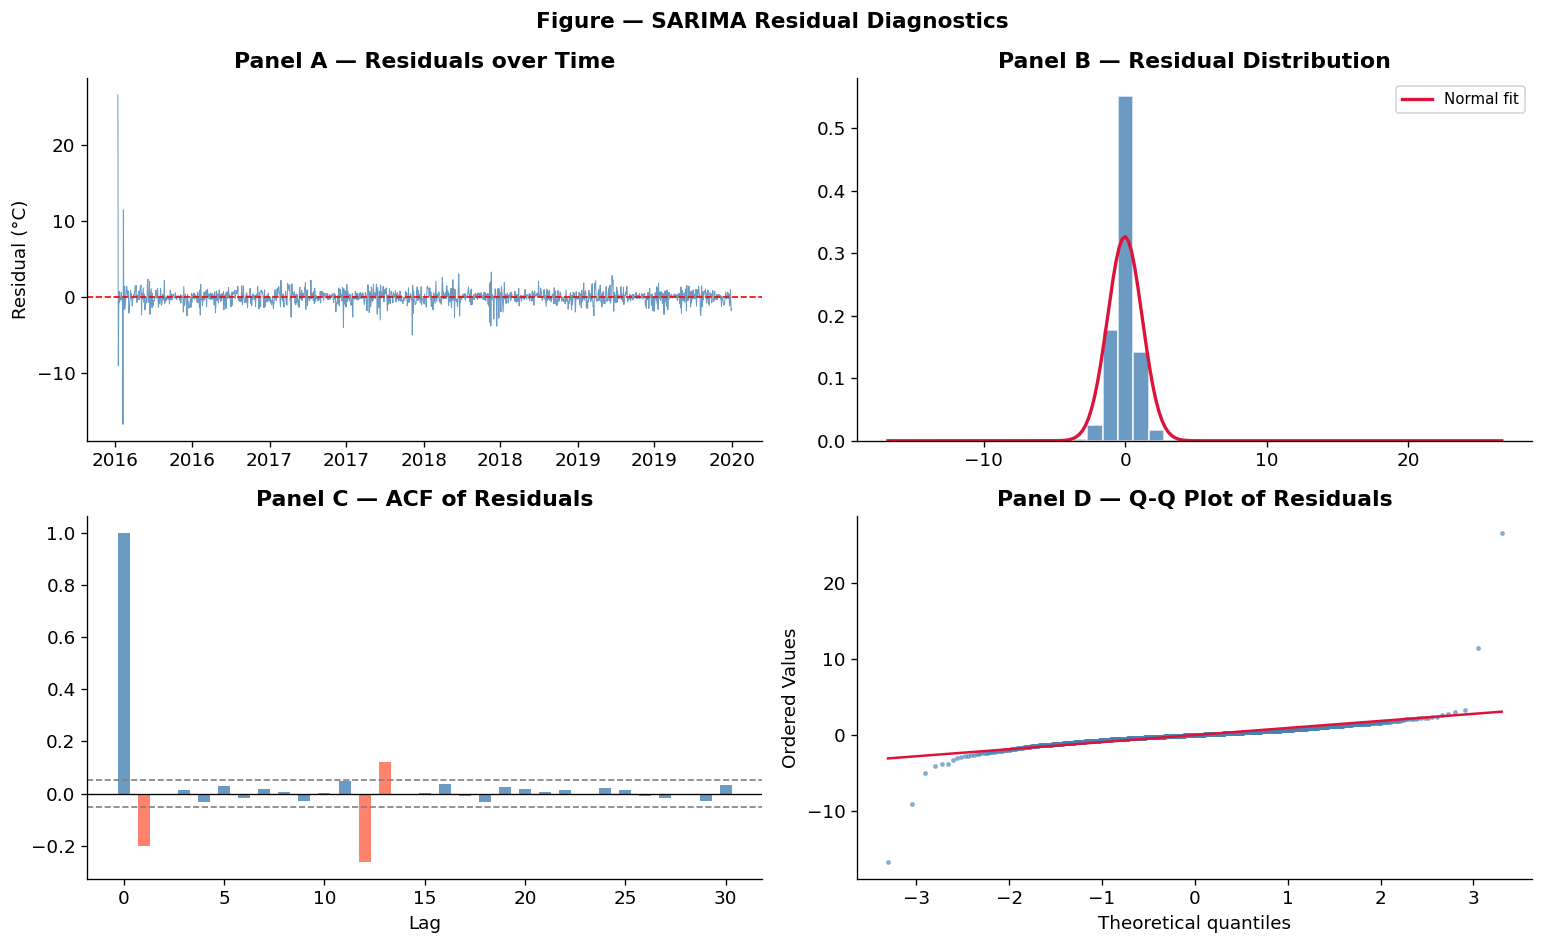


=== Ljung-Box Test — SARIMA ===
       lb_stat     lb_pvalue
10   64.326089  5.452986e-10
20  195.931322  7.166803e-31


In [10]:
residuals = sarima_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(train_scaled['datetime'], residuals,
               color='steelblue', linewidth=0.6, alpha=0.8)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title('Panel A — Residuals over Time', fontweight='bold')
axes[0,0].set_ylabel('Residual (°C)')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[0,1].hist(residuals, bins=40, color='steelblue', edgecolor='white',
               alpha=0.8, density=True)
x = np.linspace(residuals.min(), residuals.max(), 200)
axes[0,1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
               color='crimson', linewidth=2, label='Normal fit')
axes[0,1].set_title('Panel B — Residual Distribution', fontweight='bold')
axes[0,1].legend(fontsize=9)

acf_resid = acf(residuals, nlags=30, fft=True)
conf_r    = 1.96 / np.sqrt(len(residuals))
lags_r    = np.arange(len(acf_resid))
colors_r  = ['tomato' if abs(v) > conf_r and i > 0 else 'steelblue'
              for i, v in enumerate(acf_resid)]
axes[1,0].bar(lags_r, acf_resid, color=colors_r, alpha=0.8, width=0.6)
axes[1,0].axhline( conf_r, color='gray', linestyle='--', linewidth=1)
axes[1,0].axhline(-conf_r, color='gray', linestyle='--', linewidth=1)
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_title('Panel C — ACF of Residuals', fontweight='bold')
axes[1,0].set_xlabel('Lag')

stats.probplot(residuals, dist='norm', plot=axes[1,1])
axes[1,1].set_title('Panel D — Q-Q Plot of Residuals', fontweight='bold')
axes[1,1].get_lines()[0].set(markersize=2, alpha=0.5, color='steelblue')
axes[1,1].get_lines()[1].set(color='crimson', linewidth=1.5)

fig.suptitle('Figure — SARIMA Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_sarima_residuals.png', bbox_inches='tight')
plt.show()

lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
print('\n=== Ljung-Box Test — SARIMA ===')
print(lb.to_string())

### Ljung-Box Test — SARIMA: Interpretation

| Lag | LB Statistic | p-value | Decision |
|-----|-------------|---------|----------|
| 10  | 64.33       | 5.45e-10 | Reject H₀ |
| 20  | 195.93      | 7.17e-31 | Reject H₀ |

> **H₀:** Residuals are white noise (no autocorrelation)

Both lags strongly reject H₀ (p << 0.05), indicating residual autocorrelation remains. 
This is expected and attributable to the **s=12 seasonal approximation** on daily data: 
the true annual periodicity of 365 days cannot be fully represented at monthly resolution, 
leaving systematic autocorrelation at lags 12–13. 
Despite this, the out-of-sample forecast achieves R²=0.836 — 
the unmodelled autocorrelation does not severely degrade point forecast accuracy.

## 4.10 SARIMA — Rolling Forecast & Evaluation

Running SARIMA rolling forecast...
  Step 50/320
  Step 100/320
  Step 150/320
  Step 200/320
  Step 250/320
  Step 300/320

=== SARIMA Rolling Forecast — Train vs Test ===
  Train MAE  : 0.6352 °C
  Train RMSE : 1.2212 °C
  Test  MAE  : 0.6100 °C
  Test  RMSE : 0.8131 °C
  Test  MAPE : 2.2155 %
  Test  R²   : 0.8362
  Ratio RMSE : 0.67


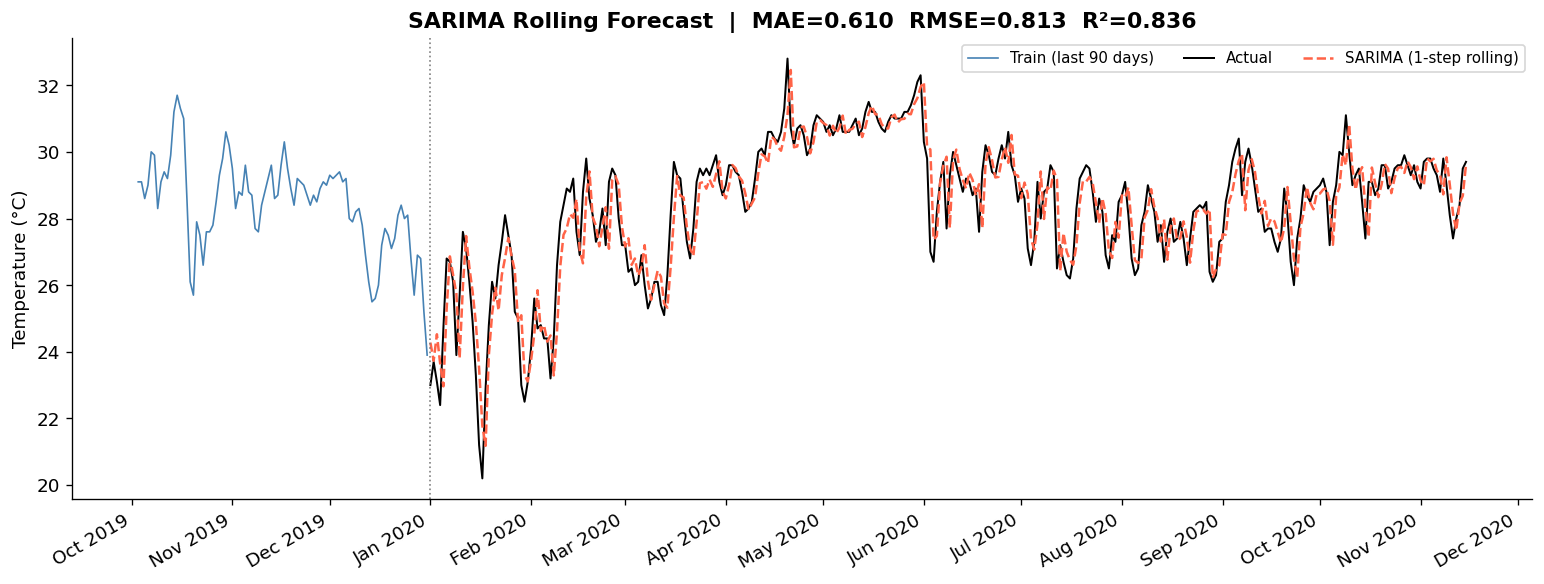

In [11]:
y_test        = test_scaled[TARGET].values
history_s     = list(train_scaled[TARGET].values)
predictions_s = []
n_test        = len(test_scaled)

print('Running SARIMA rolling forecast...')
for t in range(n_test):
    model = SARIMAX(history_s,
                    order=(p_best, d, q_best),
                    seasonal_order=(P_best, D, Q_best, s),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    fitted = model.fit(disp=False)
    yhat   = float(np.array(fitted.forecast(steps=1))[0])
    predictions_s.append(yhat)
    history_s.append(y_test[t])
    if (t + 1) % 50 == 0:
        print(f'  Step {t+1}/{n_test}')

y_pred_sarima       = np.array(predictions_s)
y_pred_sarima_train = np.array(sarima_fit.fittedvalues)
mae_s_train  = mean_absolute_error(train_scaled[TARGET].values, y_pred_sarima_train)
rmse_s_train = np.sqrt(mean_squared_error(train_scaled[TARGET].values, y_pred_sarima_train))
mae_s  = mean_absolute_error(y_test, y_pred_sarima)
rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_sarima))
mape_s = np.mean(np.abs((y_test - y_pred_sarima) / y_test)) * 100
r2_s   = r2_score(y_test, y_pred_sarima)

print('\n=== SARIMA Rolling Forecast — Train vs Test ===')
print(f'  Train MAE  : {mae_s_train:.4f} °C')
print(f'  Train RMSE : {rmse_s_train:.4f} °C')
print(f'  Test  MAE  : {mae_s:.4f} °C')
print(f'  Test  RMSE : {rmse_s:.4f} °C')
print(f'  Test  MAPE : {mape_s:.4f} %')
print(f'  Test  R²   : {r2_s:.4f}')
print(f'  Ratio RMSE : {rmse_s/rmse_s_train:.2f}')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_scaled['datetime'].iloc[-90:], train_scaled[TARGET].iloc[-90:],
        color='steelblue', linewidth=1, label='Train (last 90 days)')
ax.plot(test_scaled['datetime'], y_test, color='black', linewidth=1.2, label='Actual')
ax.plot(test_scaled['datetime'], y_pred_sarima, color='tomato',
        linewidth=1.5, linestyle='--', label='SARIMA (1-step rolling)')
ax.axvline(test_scaled['datetime'].iloc[0], color='gray', linestyle=':', linewidth=1)
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'SARIMA Rolling Forecast  |  MAE={mae_s:.3f}  RMSE={rmse_s:.3f}  R²={r2_s:.3f}',
             fontweight='bold')
ax.legend(fontsize=9, ncol=4)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_sarima_forecast.png', bbox_inches='tight')
plt.show()

## 4.11 VAR & Granger Causality Test

In [12]:
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR

EXOG_CANDIDATES = ['dew','humidity','sealevelpressure',
                   'winddir','solarradiation','windspeed','preciptype']

train_granger = train[['temp'] + EXOG_CANDIDATES].diff().dropna()
MAX_LAG = 7
granger_results = {}

print('=== Granger Causality Test ===')
print(f'{"Variable":22s}  {"Lag":>5}  {"p-value":>10}  Result')
print('-' * 58)

for col in EXOG_CANDIDATES:
    data_pair   = train_granger[['temp', col]].values
    test_result = grangercausalitytests(data_pair, maxlag=MAX_LAG, verbose=False)
    pvals = {lag: round(test_result[lag][0]['ssr_ftest'][1], 4)
             for lag in range(1, MAX_LAG + 1)}
    min_pval = min(pvals.values())
    best_lag = min(pvals, key=pvals.get)
    granger_results[col] = {'min_pval': min_pval, 'best_lag': best_lag,
                            'pvals': pvals, 'significant': min_pval < 0.05}
    sig    = '***' if min_pval<0.001 else ('**' if min_pval<0.01 else ('*' if min_pval<0.05 else 'ns'))
    result = '✓ Granger-causes temp' if min_pval < 0.05 else '✗ No effect'
    print(f'{col:22s}  lag={best_lag}  p={min_pval:.4f} {sig:>4}  {result}')

=== Granger Causality Test ===
Variable                  Lag     p-value  Result
----------------------------------------------------------
dew                     lag=1  p=0.0315    *  ✓ Granger-causes temp
humidity                lag=3  p=0.0063   **  ✓ Granger-causes temp
sealevelpressure        lag=1  p=0.0071   **  ✓ Granger-causes temp
winddir                 lag=1  p=0.0000  ***  ✓ Granger-causes temp
solarradiation          lag=5  p=0.5802   ns  ✗ No effect
windspeed               lag=3  p=0.2256   ns  ✗ No effect
preciptype              lag=6  p=0.0720   ns  ✗ No effect


In [13]:
print('=== VAR Lag Order Selection ===')
var_data  = train_granger[['temp'] + EXOG_CANDIDATES]
var_model = VAR(var_data)
lag_order = var_model.select_order(maxlags=12)
print(lag_order.summary())
print(f'\nBest lag order (AIC): {lag_order.aic}')

=== VAR Lag Order Selection ===
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        16.41       16.43   1.333e+07       16.42
1        15.72       15.98   6.685e+06       15.81
2        15.28      15.78*   4.345e+06       15.47
3        15.06       15.80   3.488e+06       15.34
4        14.94       15.91   3.088e+06      15.30*
5        14.88       16.08   2.912e+06       15.33
6        14.86       16.30   2.855e+06       15.40
7       14.85*       16.52  2.823e+06*       15.48
8        14.86       16.76   2.837e+06       15.57
9        14.87       17.01   2.880e+06       15.67
10       14.86       17.23   2.845e+06       15.75
11       14.88       17.49   2.902e+06       15.85
12       14.88       17.72   2.905e+06       15.94
--------------------------------------------------

Best lag order (AIC): 7


Significant (p < 0.05)     : ['dew', 'humidity', 'sealevelpressure', 'winddir']
Not significant (p ≥ 0.05) : ['solarradiation', 'windspeed', 'preciptype']

→ PROCEED with SARIMAX


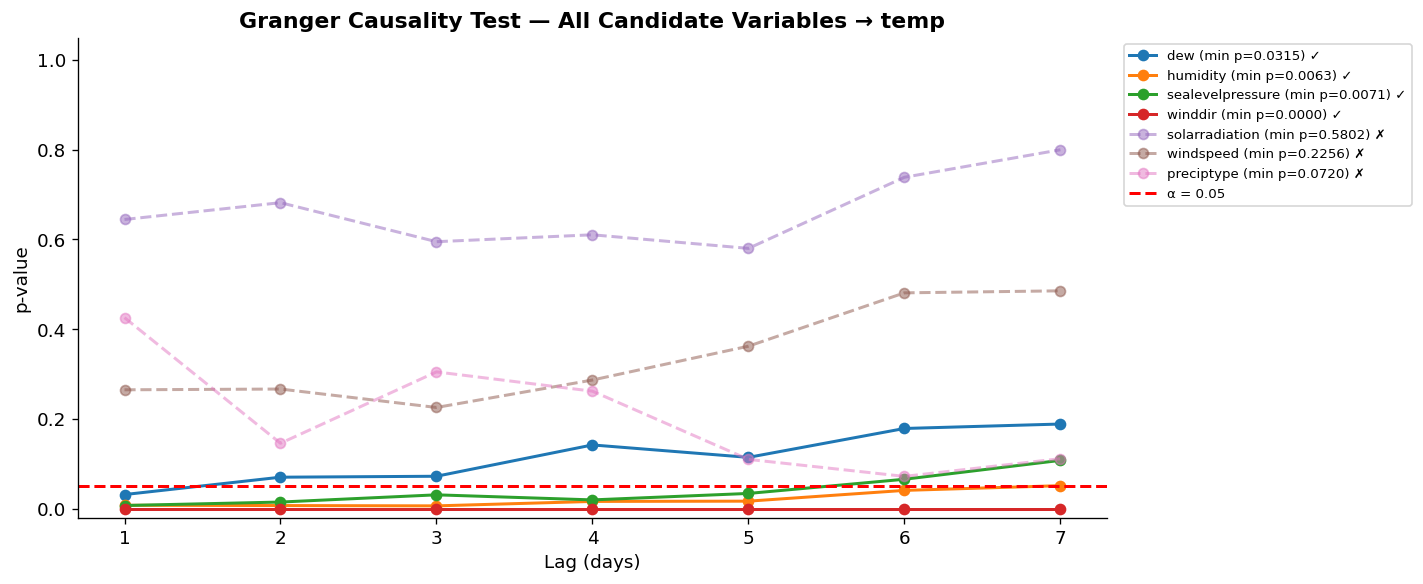

In [14]:
significant_exog = [col for col, res in granger_results.items() if res['significant']]
not_significant  = [col for col, res in granger_results.items() if not res['significant']]
proceed_sarimax  = bool(significant_exog)

print(f'Significant (p < 0.05)     : {significant_exog}')
print(f'Not significant (p ≥ 0.05) : {not_significant}')
print(f'\n→ {"PROCEED with SARIMAX" if proceed_sarimax else "SKIP SARIMAX"}')

import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(12, 5))
lags = list(range(1, MAX_LAG + 1))
for (col, res), color in zip(granger_results.items(), cm.tab10.colors):
    style = '-' if res['significant'] else '--'
    alpha = 1.0 if res['significant'] else 0.5
    ax.plot(lags, [res['pvals'][l] for l in lags], marker='o',
            linewidth=1.8, markersize=6, linestyle=style, alpha=alpha,
            color=color,
            label=f'{col} (min p={res["min_pval"]:.4f}) {"✓" if res["significant"] else "✗"}')
ax.axhline(0.05, color='red', linestyle='--', linewidth=1.8, label='α = 0.05')
ax.set_xlabel('Lag (days)')
ax.set_ylabel('p-value')
ax.set_xticks(lags)
ax.set_ylim(-0.02, 1.05)
ax.set_title('Granger Causality Test — All Candidate Variables → temp', fontweight='bold')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_granger.png', bbox_inches='tight')
plt.show()

## 4.12 SARIMAX — Fit with Exogenous Variables

In [15]:
if not proceed_sarimax:
    print('SARIMAX skipped.')
else:
    exog_train_sx = train[significant_exog].copy().values.astype(float)
    exog_test_sx  = test[significant_exog].copy().values.astype(float)
    scale_params_sx = {}

    for i, col in enumerate(significant_exog):
        mu  = train[col].mean()
        sig = train[col].std()
        scale_params_sx[col]    = {'mean': mu, 'std': sig}
        exog_train_sx[:, i] = (exog_train_sx[:, i] - mu) / sig
        exog_test_sx[:, i]  = (exog_test_sx[:, i]  - mu) / sig
        print(f'  Scaled {col:20s}: mean={mu:.3f}  std={sig:.3f}')

    print(f'\nSARIMAX order: ({p_best},{d},{q_best})({P_best},{D},{Q_best},{s})')
    print(f'Exogenous    : {significant_exog}\n')

    sarimax_model = SARIMAX(y_train, exog=exog_train_sx,
                             order=(p_best, d, q_best),
                             seasonal_order=(P_best, D, Q_best, s),
                             enforce_stationarity=False,
                             enforce_invertibility=False)
    sarimax_fit = sarimax_model.fit(disp=False)
    print(sarimax_fit.summary())

  Scaled dew                 : mean=21.500  std=4.442
  Scaled humidity            : mean=68.893  std=14.372
  Scaled sealevelpressure    : mean=1009.033  std=3.525
  Scaled winddir             : mean=203.399  std=47.577

SARIMAX order: (2,1,2)(0,1,1,12)
Exogenous    : ['dew', 'humidity', 'sealevelpressure', 'winddir']

                                      SARIMAX Results                                       
Dep. Variable:                                 temp   No. Observations:                 1454
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -384.933
Date:                              Tue, 02 Jun 2026   AIC                            789.865
Time:                                      07:48:42   BIC                            842.492
Sample:                                           0   HQIC                           809.520
                                             - 1454                                         
Covariance Type:           

## 4.13 SARIMAX — Residual Diagnostics

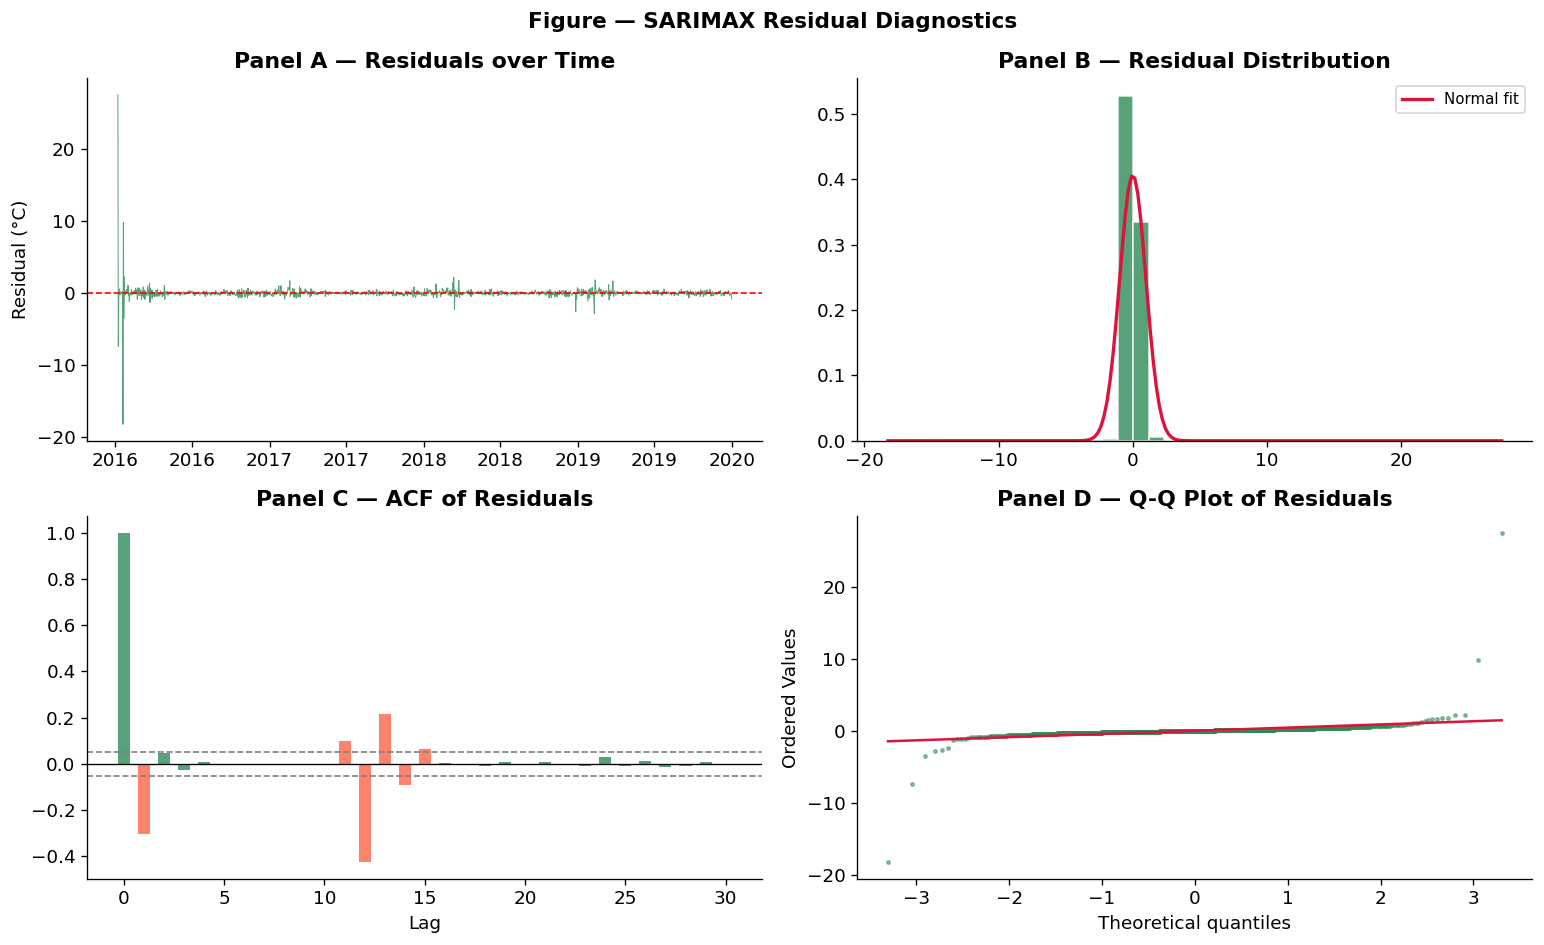


=== Ljung-Box Test — SARIMAX ===
       lb_stat     lb_pvalue
10  136.475518  2.220406e-24
20  503.246431  6.083756e-94
→ p > 0.05: white noise ✓  |  p < 0.05: residual structure remains


In [16]:
if not proceed_sarimax:
    print('SARIMAX skipped.')
else:
    resid_sx = np.array(sarimax_fit.resid)

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    axes[0,0].plot(train_scaled['datetime'], resid_sx,
                   color='seagreen', linewidth=0.6, alpha=0.8)
    axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0,0].set_title('Panel A — Residuals over Time', fontweight='bold')
    axes[0,0].set_ylabel('Residual (°C)')
    axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    axes[0,1].hist(resid_sx, bins=40, color='seagreen', edgecolor='white',
                   alpha=0.8, density=True)
    x = np.linspace(resid_sx.min(), resid_sx.max(), 200)
    axes[0,1].plot(x, stats.norm.pdf(x, resid_sx.mean(), resid_sx.std()),
                   color='crimson', linewidth=2, label='Normal fit')
    axes[0,1].set_title('Panel B — Residual Distribution', fontweight='bold')
    axes[0,1].legend(fontsize=9)

    acf_sx  = acf(resid_sx, nlags=30, fft=True)
    conf_sx = 1.96 / np.sqrt(len(resid_sx))
    lags_sx = np.arange(len(acf_sx))
    colors_sx = ['tomato' if abs(v) > conf_sx and i > 0 else 'seagreen'
                  for i, v in enumerate(acf_sx)]
    axes[1,0].bar(lags_sx, acf_sx, color=colors_sx, alpha=0.8, width=0.6)
    axes[1,0].axhline( conf_sx, color='gray', linestyle='--', linewidth=1)
    axes[1,0].axhline(-conf_sx, color='gray', linestyle='--', linewidth=1)
    axes[1,0].axhline(0, color='black', linewidth=0.8)
    axes[1,0].set_title('Panel C — ACF of Residuals', fontweight='bold')
    axes[1,0].set_xlabel('Lag')

    stats.probplot(resid_sx, dist='norm', plot=axes[1,1])
    axes[1,1].set_title('Panel D — Q-Q Plot of Residuals', fontweight='bold')
    axes[1,1].get_lines()[0].set(markersize=2, alpha=0.5, color='seagreen')
    axes[1,1].get_lines()[1].set(color='crimson', linewidth=1.5)

    fig.suptitle('Figure — SARIMAX Residual Diagnostics', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_sarimax_residuals.png', bbox_inches='tight')
    plt.show()

    lb_sx = acorr_ljungbox(resid_sx, lags=[10, 20], return_df=True)
    print('\n=== Ljung-Box Test — SARIMAX ===')
    print(lb_sx.to_string())
    print('→ p > 0.05: white noise ✓  |  p < 0.05: residual structure remains')

## 4.14 SARIMAX — Rolling Forecast & 95% CI

Running SARIMAX rolling forecast...
  Step 50/320
  Step 100/320
  Step 150/320
  Step 200/320
  Step 250/320
  Step 300/320

=== SARIMAX Rolling Forecast — Train vs Test ===
  Exogenous vars         : ['dew', 'humidity', 'sealevelpressure', 'winddir']
  Train MAE              : 0.2580 °C
  Train RMSE             : 0.9818 °C
  Test  MAE              : 0.2310 °C
  Test  RMSE             : 0.3129 °C
  Test  MAPE             : 0.8316 %
  Test  R²               : 0.9758
  Ratio RMSE (test/train): 0.32
  95% CI coverage        : 94.7%  (expected ≈ 95%)


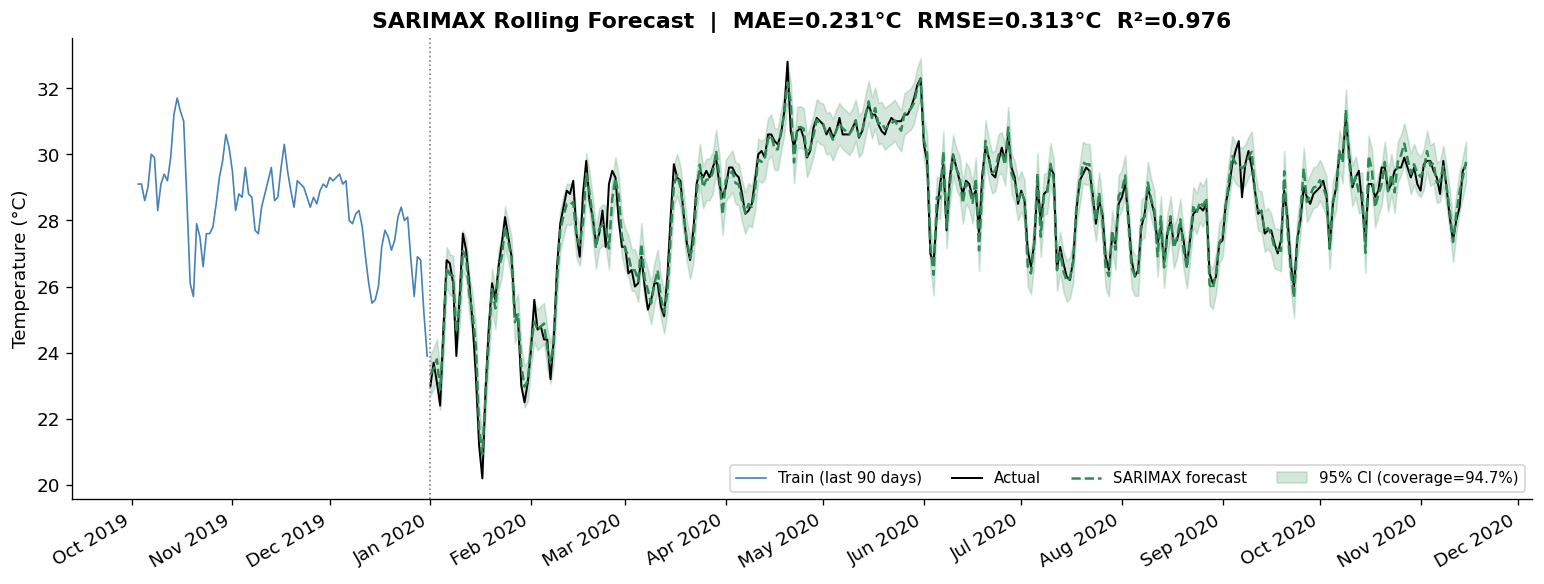

In [17]:
if not proceed_sarimax:
    print('SARIMAX skipped.')
    mae_sx = rmse_sx = mape_sx = r2_sx = None
    y_pred_sarimax = None
else:
    history_sx   = list(train_scaled[TARGET].values)
    exog_hist_sx = list(exog_train_sx)
    preds_sx     = []
    ci_lower     = []
    ci_upper     = []

    print('Running SARIMAX rolling forecast...')
    for t in range(n_test):
        model = SARIMAX(history_sx, exog=exog_hist_sx,
                        order=(p_best, d, q_best),
                        seasonal_order=(P_best, D, Q_best, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        fitted    = model.fit(disp=False)
        exog_next = exog_test_sx[t].reshape(1, -1)
        fc        = fitted.get_forecast(steps=1, exog=exog_next)

        yhat   = float(np.array(fc.predicted_mean)[0])
        ci_arr = np.array(fc.conf_int(alpha=0.05))
        lo     = float(ci_arr[0, 0])
        hi     = float(ci_arr[0, 1])

        preds_sx.append(yhat)
        ci_lower.append(lo)
        ci_upper.append(hi)
        history_sx.append(y_test[t])
        exog_hist_sx.append(exog_test_sx[t])

        if (t + 1) % 50 == 0:
            print(f'  Step {t+1}/{n_test}')

    y_pred_sarimax = np.array(preds_sx)
    ci_lower       = np.array(ci_lower)
    ci_upper       = np.array(ci_upper)

    y_pred_sarimax_train = np.array(sarimax_fit.fittedvalues)
    mae_sx_train  = mean_absolute_error(train_scaled[TARGET].values, y_pred_sarimax_train)
    rmse_sx_train = np.sqrt(mean_squared_error(train_scaled[TARGET].values, y_pred_sarimax_train))
    mae_sx   = mean_absolute_error(y_test, y_pred_sarimax)
    rmse_sx  = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
    mape_sx  = np.mean(np.abs((y_test - y_pred_sarimax) / y_test)) * 100
    r2_sx    = r2_score(y_test, y_pred_sarimax)
    coverage = np.mean((y_test >= ci_lower) & (y_test <= ci_upper)) * 100

    print('\n=== SARIMAX Rolling Forecast — Train vs Test ===')
    print(f'  Exogenous vars         : {significant_exog}')
    print(f'  Train MAE              : {mae_sx_train:.4f} °C')
    print(f'  Train RMSE             : {rmse_sx_train:.4f} °C')
    print(f'  Test  MAE              : {mae_sx:.4f} °C')
    print(f'  Test  RMSE             : {rmse_sx:.4f} °C')
    print(f'  Test  MAPE             : {mape_sx:.4f} %')
    print(f'  Test  R²               : {r2_sx:.4f}')
    print(f'  Ratio RMSE (test/train): {rmse_sx/rmse_sx_train:.2f}')
    print(f'  95% CI coverage        : {coverage:.1f}%  (expected ≈ 95%)')

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train_scaled['datetime'].iloc[-90:], train_scaled[TARGET].iloc[-90:],
            color='steelblue', linewidth=1, label='Train (last 90 days)')
    ax.plot(test_scaled['datetime'], y_test,
            color='black', linewidth=1.2, label='Actual')
    ax.plot(test_scaled['datetime'], y_pred_sarimax,
            color='seagreen', linewidth=1.5, linestyle='--',
            label='SARIMAX forecast')
    ax.fill_between(test_scaled['datetime'], ci_lower, ci_upper,
                    color='seagreen', alpha=0.2,
                    label=f'95% CI (coverage={coverage:.1f}%)')
    ax.axvline(test_scaled['datetime'].iloc[0], color='gray', linestyle=':', linewidth=1)
    ax.set_ylabel('Temperature (°C)')
    ax.set_title(
        f'SARIMAX Rolling Forecast  |  MAE={mae_sx:.3f}°C  RMSE={rmse_sx:.3f}°C  R²={r2_sx:.3f}',
        fontweight='bold')
    ax.legend(fontsize=9, ncol=4)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('fig_sarimax_forecast.png', bbox_inches='tight')
    plt.show()

## 4.15 XGBoost — Feature Preparation

In [18]:
from xgboost import XGBRegressor

XGB_FEATURES = [
    'dew', 'humidity', 'sealevelpressure', 'winddir',
    'solarradiation', 'windspeed', 'preciptype',
    'month', 'quarter', 'dayofyear', 'season',
    'sin_doy', 'cos_doy', 'sin_month', 'cos_month',
    'temp_lag1', 'temp_lag7',
    'dew_lag1', 'sealevelpressure_lag1',
    'temp_rollmean7'
]

# Use original train/test (not scaled versions)
X_train     = train[XGB_FEATURES].copy()
X_test      = test[XGB_FEATURES].copy()
y_train_xgb = train[TARGET].values
y_test_xgb  = test[TARGET].values

# Scale all numeric features — fit on train only
scale_cols_xgb = ['dew', 'humidity', 'sealevelpressure', 'winddir',
                   'solarradiation', 'windspeed',
                   'temp_lag1', 'temp_lag7', 'temp_rollmean7',
                   'dew_lag1', 'sealevelpressure_lag1']

for col in scale_cols_xgb:
    mu  = X_train[col].mean()
    sig = X_train[col].std()
    X_train[col] = (X_train[col] - mu) / sig
    X_test[col]  = (X_test[col]  - mu) / sig

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'Features: {XGB_FEATURES}')

X_train : (1454, 20)  |  X_test : (320, 20)
Features: ['dew', 'humidity', 'sealevelpressure', 'winddir', 'solarradiation', 'windspeed', 'preciptype', 'month', 'quarter', 'dayofyear', 'season', 'sin_doy', 'cos_doy', 'sin_month', 'cos_month', 'temp_lag1', 'temp_lag7', 'dew_lag1', 'sealevelpressure_lag1', 'temp_rollmean7']


## 4.16 XGBoost — Fit & Evaluate

In [19]:
xgb_model = XGBRegressor(
    n_estimators         = 300,
    max_depth            = 3,
    learning_rate        = 0.05,
    subsample            = 0.7,
    colsample_bytree     = 0.7,
    min_child_weight     = 5,
    reg_alpha            = 0.1,
    reg_lambda           = 1.5,
    random_state         = 42,
    early_stopping_rounds= 30,
    eval_metric          = 'rmse',
    n_jobs               = -1,
    tree_method          = 'hist'
)

xgb_model.fit(X_train, y_train_xgb,
              eval_set=[(X_test, y_test_xgb)],
              verbose=50)

y_pred_xgb_train = xgb_model.predict(X_train)
mae_xgb_train    = mean_absolute_error(y_train_xgb, y_pred_xgb_train)
rmse_xgb_train   = np.sqrt(mean_squared_error(y_train_xgb, y_pred_xgb_train))

y_pred_xgb = xgb_model.predict(X_test)
mae_xgb    = mean_absolute_error(y_test_xgb, y_pred_xgb)
rmse_xgb   = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
mape_xgb   = np.mean(np.abs((y_test_xgb - y_pred_xgb) / y_test_xgb)) * 100
r2_xgb     = r2_score(y_test_xgb, y_pred_xgb)

print('\n=== XGBoost — Train vs Test Evaluation ===')
print(f'  Train MAE  : {mae_xgb_train:.4f} °C')
print(f'  Train RMSE : {rmse_xgb_train:.4f} °C')
print(f'  Test  MAE  : {mae_xgb:.4f} °C')
print(f'  Test  RMSE : {rmse_xgb:.4f} °C')
print(f'  Test  MAPE : {mape_xgb:.4f} %')
print(f'  Test  R²   : {r2_xgb:.4f}')
print(f'  Ratio RMSE : {rmse_xgb/rmse_xgb_train:.2f}')
print(f'  Best iter  : {xgb_model.best_iteration}')

[0]	validation_0-rmse:1.94831
[50]	validation_0-rmse:0.74603
[100]	validation_0-rmse:0.62965
[150]	validation_0-rmse:0.57561
[200]	validation_0-rmse:0.54740
[250]	validation_0-rmse:0.52086
[299]	validation_0-rmse:0.50131

=== XGBoost — Train vs Test Evaluation ===
  Train MAE  : 0.2647 °C
  Train RMSE : 0.3533 °C
  Test  MAE  : 0.3532 °C
  Test  RMSE : 0.5012 °C
  Test  MAPE : 1.2899 %
  Test  R²   : 0.9378
  Ratio RMSE : 1.42
  Best iter  : 298


## 4.17 XGBoost — Feature Importance

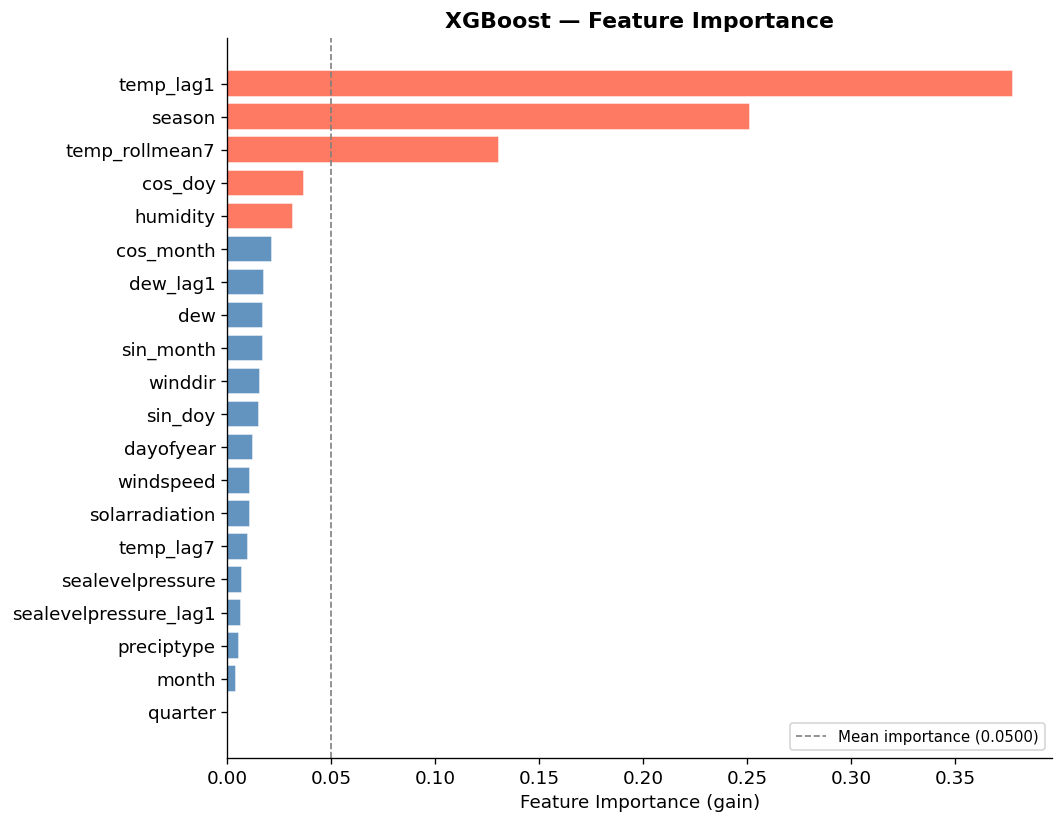

=== Top 10 Features ===
temp_lag1         0.3777
season            0.2515
temp_rollmean7    0.1307
cos_doy           0.0370
humidity          0.0314
cos_month         0.0214
dew_lag1          0.0178
dew               0.0172
sin_month         0.0170
winddir           0.0155


In [20]:
importance = pd.Series(xgb_model.feature_importances_,
                       index=XGB_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['tomato' if v >= importance.quantile(0.75) else 'steelblue'
          for v in importance.values]
ax.barh(importance.index, importance.values, color=colors,
        edgecolor='white', alpha=0.85)
ax.axvline(importance.mean(), color='gray', linestyle='--',
            linewidth=1, label=f'Mean importance ({importance.mean():.4f})')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost — Feature Importance', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_xgb_importance.png', bbox_inches='tight')
plt.show()
print('=== Top 10 Features ===')
print(importance.sort_values(ascending=False).head(10).round(4).to_string())

## 4.18 XGBoost — Forecast Plot

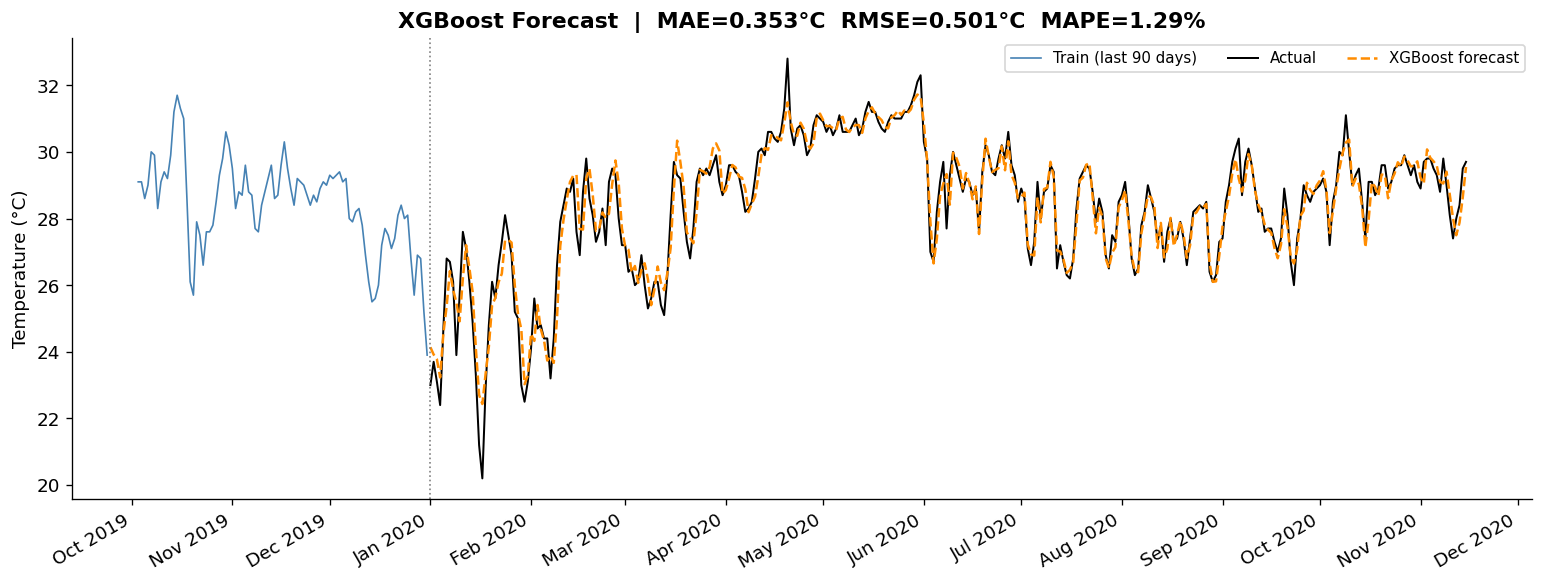

In [21]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train['datetime'].iloc[-90:], train[TARGET].iloc[-90:],
        color='steelblue', linewidth=1, label='Train (last 90 days)')
ax.plot(test['datetime'], y_test_xgb, color='black', linewidth=1.2, label='Actual')
ax.plot(test['datetime'], y_pred_xgb, color='darkorange',
        linewidth=1.5, linestyle='--', label='XGBoost forecast')
ax.axvline(test['datetime'].iloc[0], color='gray', linestyle=':', linewidth=1)
ax.set_ylabel('Temperature (°C)')
ax.set_title(
    f'XGBoost Forecast  |  MAE={mae_xgb:.3f}°C  RMSE={rmse_xgb:.3f}°C  MAPE={mape_xgb:.2f}%',
    fontweight='bold')
ax.legend(fontsize=9, ncol=4)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_xgb_forecast.png', bbox_inches='tight')
plt.show()

## 4.19 Model Comparison

In [22]:
comparison = pd.DataFrame({
    'Model'       : ['SARIMA', 'SARIMAX', 'XGBoost'],
    'Type'        : ['Statistical', 'Statistical', 'Machine Learning'],
    'AIC'         : [round(sarima_fit.aic, 2), round(sarimax_fit.aic, 2), 'N/A'],
    'BIC'         : [round(sarima_fit.bic, 2), round(sarimax_fit.bic, 2), 'N/A'],
    'Train RMSE'  : [round(rmse_s_train,   4), round(rmse_sx_train, 4), round(rmse_xgb_train, 4)],
    'Test MAE'    : [round(mae_s,    4), round(mae_sx,  4), round(mae_xgb,  4)],
    'Test RMSE'   : [round(rmse_s,   4), round(rmse_sx, 4), round(rmse_xgb, 4)],
    'Test MAPE(%)': [round(mape_s,   4), round(mape_sx, 4), round(mape_xgb, 4)],
    'Test R²'     : [round(r2_s,     4), round(r2_sx,   4), round(r2_xgb,   4)],
    'RMSE ratio'  : [round(rmse_s/rmse_s_train,   2),
                     round(rmse_sx/rmse_sx_train,  2),
                     round(rmse_xgb/rmse_xgb_train, 2)]
})
print('=== Model Comparison: SARIMA vs SARIMAX vs XGBoost ===')
print(comparison.to_string(index=False))

print('\n=== Best Model per Metric ===')
for metric in ['Test MAE', 'Test RMSE', 'Test MAPE(%)', 'Test R²']:
    vals  = comparison[metric].values
    names = comparison['Model'].values
    if metric == 'Test R²':
        best_idx = int(np.argmax([float(v) for v in vals]))
    else:
        best_idx = int(np.argmin([float(v) for v in vals]))
    print(f'  {metric:15s}: {names[best_idx]} ({vals[best_idx]})')

=== Model Comparison: SARIMA vs SARIMAX vs XGBoost ===
  Model             Type      AIC      BIC  Train RMSE  Test MAE  Test RMSE  Test MAPE(%)  Test R²  RMSE ratio
 SARIMA      Statistical  3470.46  3502.03      1.2212    0.6100     0.8131        2.2155   0.8362        0.67
SARIMAX      Statistical   789.87   842.49      0.9818    0.2310     0.3129        0.8316   0.9758        0.32
XGBoost Machine Learning      N/A      N/A      0.3533    0.3532     0.5012        1.2899   0.9378        1.42

=== Best Model per Metric ===
  Test MAE       : SARIMAX (0.231)
  Test RMSE      : SARIMAX (0.3129)
  Test MAPE(%)   : SARIMAX (0.8316)
  Test R²        : SARIMAX (0.9758)


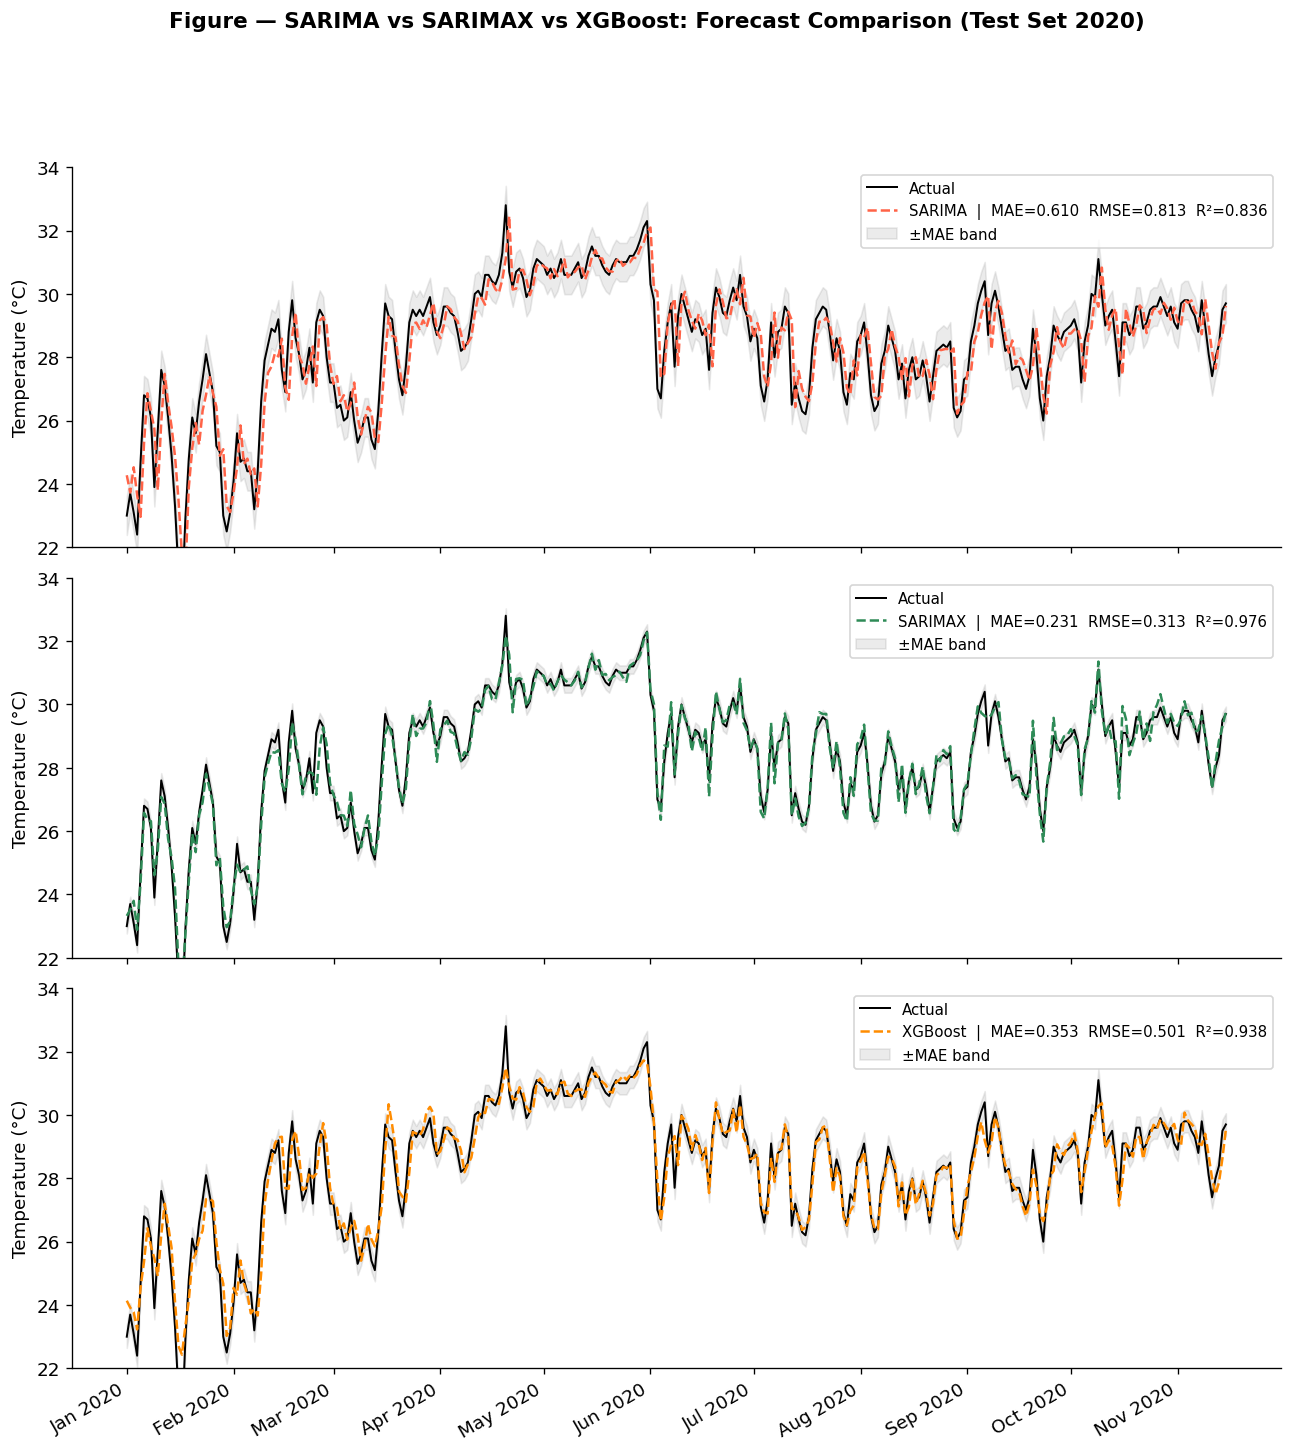

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(13, 13), sharex=True,
                          gridspec_kw={'hspace': 0.08})
model_info = [
    (y_pred_sarima,  'tomato',     'SARIMA',   mae_s,   rmse_s,   r2_s),
    (y_pred_sarimax, 'seagreen',   'SARIMAX',  mae_sx,  rmse_sx,  r2_sx),
    (y_pred_xgb,     'darkorange', 'XGBoost',  mae_xgb, rmse_xgb, r2_xgb),
]
for ax, (y_pred, color, label, mae, rmse, r2) in zip(axes, model_info):
    ax.plot(test_scaled['datetime'], y_test,
            color='black', linewidth=1.2, label='Actual')
    ax.plot(test_scaled['datetime'], y_pred, color=color,
            linewidth=1.5, linestyle='--',
            label=f'{label}  |  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}')
    ax.fill_between(test_scaled['datetime'], y_test-mae, y_test+mae,
                    alpha=0.08, color='black', label='±MAE band')
    ax.set_ylabel('Temperature (°C)')
    ax.legend(fontsize=9, loc='upper right')
    ax.set_ylim(22, 34)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
fig.suptitle('Figure — SARIMA vs SARIMAX vs XGBoost: Forecast Comparison (Test Set 2020)',
             fontsize=13, fontweight='bold')
plt.savefig('fig_model_comparison.png', bbox_inches='tight')
plt.show()